In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 05. 木ベースのモデル — 決定木・ランダムフォレスト・勾配ブースティング

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 決定木が **不純度(Gini / エントロピー)** を下げる分割を貪欲に選ぶこと
- 木は **過学習** しやすく、深さ・葉のサイズで複雑さを制御すること
- **バギング / ランダムフォレスト** が多数の木で **バリアンスを下げる** こと
- **勾配ブースティング** が残差を順に当てて **バイアスを下げる** こと
- XGBoost / LightGBM / CatBoost は同じ勾配ブースティングの高速実装であること
- **特徴量重要度** の読み方と落とし穴(不純度ベースの偏り)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, widgets

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 決定木の分割と不純度

決定木は「ある特徴がしきい値より上か下か」で領域を二分し、各領域をできるだけ **純粋**(1 クラスだけ)にします。
純粋さの尺度が **不純度**:

$$
\text{Gini} = 1 - \sum_k p_k^2, \qquad \text{Entropy} = -\sum_k p_k \log_2 p_k
$$

$p_k$ はその領域でのクラス $k$ の割合。分割は **不純度の加重平均が最も下がる**(=情報利得が最大の)ものを選びます。

In [3]:
def gini(counts):
    counts = np.asarray(counts, float); p = counts / counts.sum()
    return 1 - np.sum(p**2)

parent = [50, 50]
# A split sends most of one class left, most of the other right.
left, right = [45, 10], [5, 40]
n = sum(parent)
weighted = (sum(left)/n)*gini(left) + (sum(right)/n)*gini(right)
print(f"parent Gini      = {gini(parent):.3f}")
print(f"weighted child Gini = {weighted:.3f}")
print(f"information gain  = {gini(parent) - weighted:.3f}  (the tree maximizes this)")

parent Gini      = 0.500
weighted child Gini = 0.253
information gain  = 0.247  (the tree maximizes this)


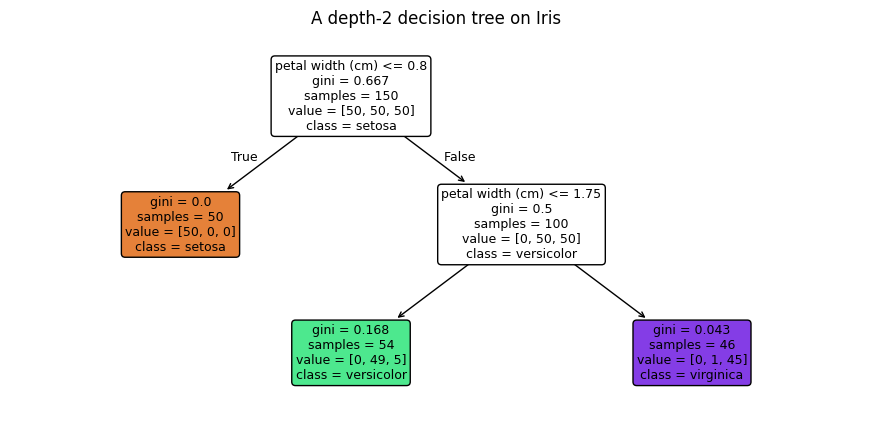

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = datasets.load_iris_dataset()
tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(iris.data, iris.target)
fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(tree, feature_names=iris.feature_names, class_names=list(iris.target_names),
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("A depth-2 decision tree on Iris"); plt.show()

## 2. 木は過学習する — 深さで複雑さを制御

深い木は訓練データを丸暗記し、境界がギザギザになります。深さは最も基本的な制御つまみです。

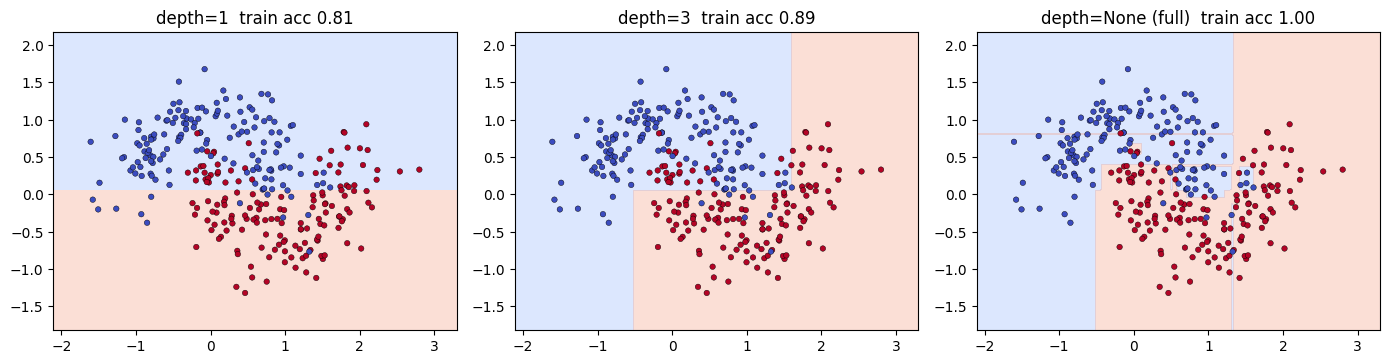

In [5]:
X, y = datasets.make_moons_dataset(n=300, noise=0.3, seed=0)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, depth in zip(axes, [1, 3, None]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X, y)
    label = f"depth={depth}" if depth else "depth=None (full)"
    plotting.plot_decision_boundary(clf.predict, X, y, ax=ax, steps=200,
                                    title=f"{label}  train acc {clf.score(X, y):.2f}")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### インタラクティブ: 木の深さと決定境界(静的 HTML 可)

深さを上げると領域が細かく刻まれ、訓練データに食い込んでいきます(過学習)。

In [6]:
depths = [1, 2, 3, 5, 8, 15]
pad = 0.5
xs = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 120)
ys = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 120)
xx, yy = np.meshgrid(xs, ys)
grid = np.c_[xx.ravel(), yy.ravel()]
frames = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X, y)
    Z = clf.predict(grid).reshape(xx.shape)
    frames.append(go.Frame(name=str(d), data=[
        go.Heatmap(x=xs, y=ys, z=Z, colorscale="RdBu", showscale=False, opacity=0.7),
        go.Scatter(x=list(X[:, 0]), y=list(X[:, 1]), mode="markers",
                   marker={"color": list(map(int, y)), "colorscale": "RdBu",
                           "line": {"color": "black", "width": 0.5}, "size": 6}, showlegend=False),
    ], layout={"title": f"max_depth = {d}  (train acc {clf.score(X, y):.2f})"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "max_depth = "}}],
                  title=frames[0].layout.title.text, width=600, height=560,
                  xaxis={"title": "x1"}, yaxis={"title": "x2", "scaleanchor": "x"},
                  margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

### インタラクティブ(JupyterLab のみ): 木の深さ

スライダーで深さを上げると訓練精度は 1.0 に近づくのにテスト精度は頭打ち/低下します(過学習)。

In [7]:
widgets.decision_tree_depth_explorer(X, y)

interactive(children=(IntSlider(value=3, description='depth', max=15, min=1), Output()), _dom_classes=('widget…

<function ml_textbook.widgets.decision_tree_depth_explorer.<locals>.draw(depth)>

## 3. バギングとランダムフォレスト — バリアンスを下げる

深い木は **低バイアス・高バリアンス**(データが少し変わると境界が大きく変わる)。
**バギング** は、ブートストラップ標本で多数の木を育て、予測を平均(分類は多数決)してバリアンスを下げます。
**ランダムフォレスト** はさらに、各分割で使う特徴をランダムに絞り、木同士の相関を下げます。

下: 個々の深い木の境界はバラバラ。森(平均)はなめらかで安定します。

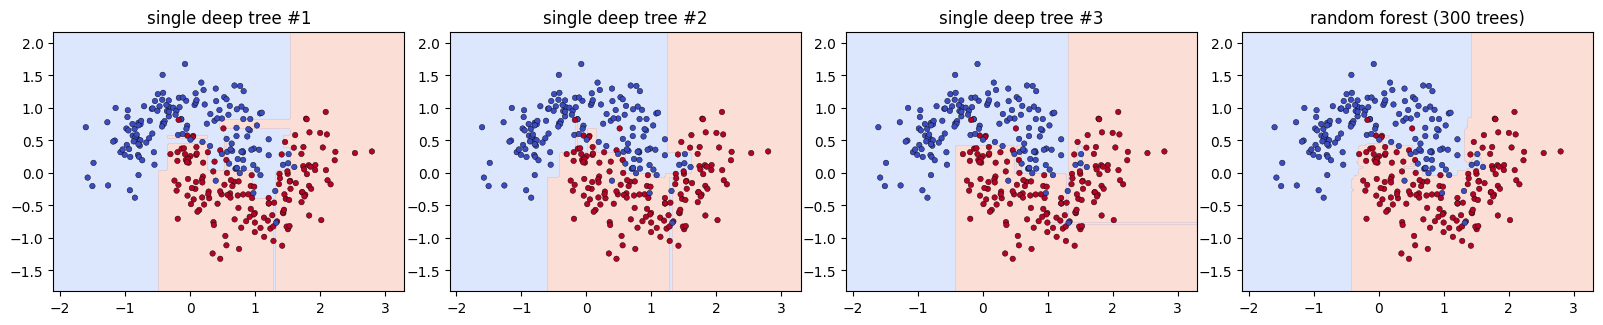

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(3):
    Xb, yb = resample(X, y, random_state=i)
    t = DecisionTreeClassifier(max_depth=None, random_state=0).fit(Xb, yb)
    plotting.plot_decision_boundary(t.predict, X, y, ax=axes[i], steps=150, title=f"single deep tree #{i+1}")
    axes[i].set_aspect("equal")
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X, y)
plotting.plot_decision_boundary(rf.predict, X, y, ax=axes[3], steps=150, title="random forest (300 trees)")
axes[3].set_aspect("equal")
plt.tight_layout(); plt.show()

## 4. 勾配ブースティング — バイアスを下げる

ブースティングは弱い木を **順番に** 足し、前段の **残差(誤り)** を次の木が当てます。
浅い木を少しずつ積むことで、バイアスを段階的に削っていきます。下のスライダーで木の本数を増やすと、
フィットが滑らかに改善していく様子が見えます(静的 HTML 可)。

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

xr = np.linspace(-3, 3, 200)
yr = np.sin(1.5 * xr) + 0.3 * xr + 0.2 * np.random.default_rng(0).standard_normal(200)
Xr = xr[:, None]
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.2, max_depth=2).fit(Xr, yr)
stages = np.array(list(gbr.staged_predict(Xr)))   # prediction after each added tree
picks = [1, 2, 5, 10, 20, 40, 80, 160]

frames = []
for k in picks:
    frames.append(go.Frame(name=str(k), data=[
        go.Scatter(x=list(xr), y=list(yr), mode="markers", marker={"size": 4, "color": "#bbb"}, name="data"),
        go.Scatter(x=list(xr), y=list(stages[k - 1]), mode="lines", line={"color": "#d62728", "width": 3}, name="fit"),
    ], layout={"title": f"after {k} trees"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "trees = "}}],
                  title="Boosting corrects its own residuals step by step",
                  width=720, height=460, xaxis_title="x", yaxis_title="y",
                  margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

## 5. scikit-learn の木モデルを比べる

`HistGradientBoostingClassifier` はヒストグラム化で高速・高精度な勾配ブースティングです。
**XGBoost / LightGBM / CatBoost** は同じ勾配ブースティングの高速実装(外部ライブラリ)で、
考え方はここで学んだものと同じです。本書は追加依存を避け、scikit-learn 実装で進めます。

In [10]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

wine = datasets.load_wine_dataset()
Xw, yw = wine.data, wine.target
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=0),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0),
    "GradientBoosting": GradientBoostingClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
}
for name, m in models.items():
    s = cross_val_score(m, Xw, yw, cv=5)
    print(f"{name:22s} CV acc = {s.mean():.3f} +/- {s.std():.3f}")

DecisionTree           CV acc = 0.916 +/- 0.039


RandomForest           CV acc = 0.967 +/- 0.021


GradientBoosting       CV acc = 0.939 +/- 0.032


HistGradientBoosting   CV acc = 0.955 +/- 0.022


## 6. 特徴量重要度とその落とし穴

木モデルは「分割でどれだけ不純度を下げたか」で **重要度** を出せます。ただし不純度ベースの重要度は
**カテゴリ数や連続値の多い特徴を過大評価** する偏りがあります。**Permutation importance**(09 章で詳述)は
モデル非依存で偏りが小さく、こちらと併用するのが安全です。

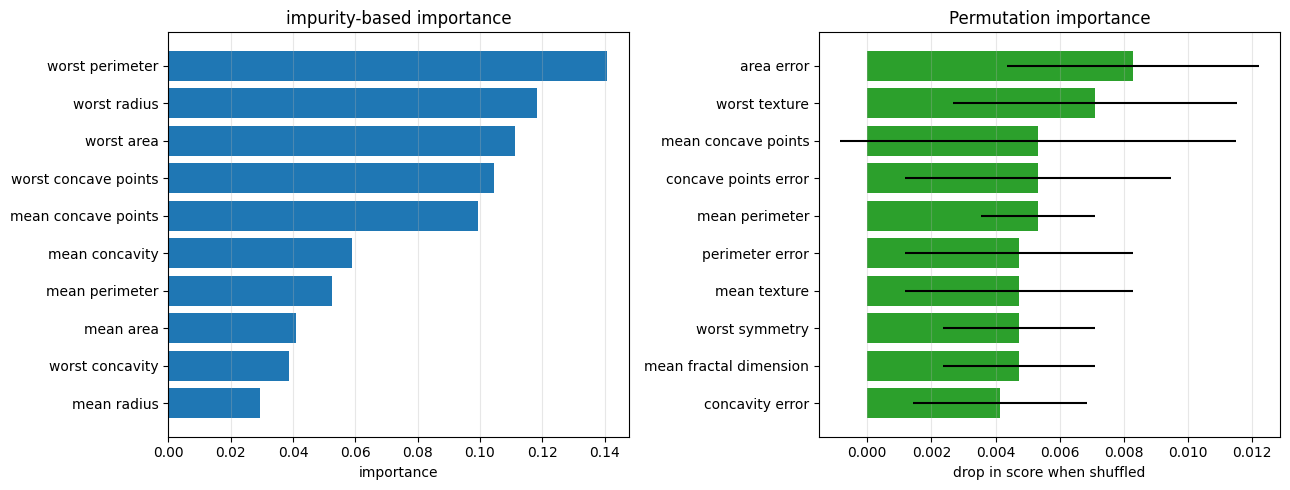

In [11]:
from sklearn.inspection import permutation_importance

bc = datasets.load_breast_cancer_dataset()
Xb_tr, Xb_te, yb_tr, yb_te = (
    bc.data.iloc[:400], bc.data.iloc[400:], bc.target.iloc[:400], bc.target.iloc[400:]
)
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xb_tr, yb_tr)
perm = permutation_importance(rf, Xb_te, yb_te, n_repeats=10, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plotting.plot_feature_importance(bc.feature_names, rf.feature_importances_, ax=axes[0], top=10,
                                 title="impurity-based importance")
plotting.plot_permutation_importance(perm, bc.feature_names, ax=axes[1], top=10)
plt.tight_layout(); plt.show()

## 7. まとめ

- 決定木は不純度(Gini/エントロピー)を最大に下げる分割を貪欲に選ぶ。単体は **過学習** しやすい。
- **ランダムフォレスト** = バギング + 特徴のランダム化。多数の木で **バリアンスを下げる**。
- **勾配ブースティング** = 残差を順に当てる。浅い木で **バイアスを下げる**。XGBoost 等は同じ考え方の高速実装。
- 木モデルは **スケーリング不要**、非線形・相互作用を自然に扱える。
- 重要度は不純度ベースに偏りがあるので **permutation importance** と併用する。

## 8. Exercises

1. `entropy` 基準(`criterion="entropy"`)に変えて Iris の木の形が変わるか確認せよ。
2. ランダムフォレストの `n_estimators` を 1 → 300 と増やし、決定境界の滑らかさの変化を見よ。
3. 勾配ブースティングの `learning_rate` を 0.05 と 0.5 にして、必要な木の本数がどう変わるか観察せよ。
4. Wine で `max_depth` を制限した RF と無制限の RF の CV を比べよ。
5. (発展)不純度重要度と permutation 重要度で順位が入れ替わる特徴を見つけ、理由を考えよ。

## 9. Common Mistakes

- **単体の深い木をそのまま使う。** 過学習。森かブースティングにするか、深さ/葉サイズで制御。
- **木モデルに標準化が要ると思う。** 不要(順序しか見ない)。
- **不純度重要度だけを信じる。** 高カーディナリティ特徴に偏る。permutation と併用。
- **ブースティングで学習率を上げて木も増やす。** 過学習。学習率と本数はトレードオフ。

## 10. Advanced Notes

**バイアス-バリアンスの観点。** RF は「低バイアス・高バリアンス」な木を平均してバリアンスを下げる approach、
ブースティングは「高バイアス・低バリアンス」な浅い木を足してバイアスを下げる approach。
向かう方向が逆である点を押さえると、ハイパーパラメータ(木の深さ・本数・学習率)の意味が見通せる。